In [5]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [6]:
np.random.seed(0)

In [13]:
data={
    "student-id":np.random.randint(1,100,250),
    "name":np.random.choice(["A","B","C","D"],250),
    "gender":np.random.choice(["M","F"],250),
    "department":np.random.choice(["CSE","ECE","MECH","CIVIL"],250),
    "year":np.random.choice(["1st","2nd","3rd","4th"],250),
    "maths":np.random.randint(0,100,250),
    "science":np.random.randint(0,100,250),
    "English":np.random.randint(0,100,250),
    "Attendence":np.random.randint(0,100,250),
    "Internal_Marks":np.random.randint(0,100,250),
    }

In [14]:
df=pd.DataFrame(data)

In [15]:
df

,student-id,name,gender,department,year,maths,science,English,Attendence,Internal_Marks
0,59,A,M,ECE,2nd,78,30,17,15,92
1,6,D,F,ECE,4th,6,91,3,88,47
2,74,B,M,CSE,4th,47,51,8,14,32
3,89,C,F,ECE,3rd,44,4,47,10,33
4,13,B,M,CIVIL,2nd,9,68,43,4,99
...,...,...,...,...,...,...,...,...,...,...
245,81,D,M,CSE,3rd,98,6,4,21,96
246,83,B,M,MECH,3rd,91,7,16,21,39
247,51,C,F,MECH,3rd,62,51,98,57,50
248,62,B,F,MECH,4th,62,77,56,90,0


In [16]:
pip install faker

In [17]:

from faker import Faker
fake=Faker()
df["name"]=[fake.name() for _ in range(250)]
df

,student-id,name,gender,department,year,maths,science,English,Attendence,Internal_Marks
0,59,Susan Sutton,M,ECE,2nd,78,30,17,15,92
1,6,Logan Coleman,F,ECE,4th,6,91,3,88,47
2,74,Candice Brown,M,CSE,4th,47,51,8,14,32
3,89,David Wall,F,ECE,3rd,44,4,47,10,33
4,13,Crystal Perry,M,CIVIL,2nd,9,68,43,4,99
...,...,...,...,...,...,...,...,...,...,...
245,81,Jessica Garrett,M,CSE,3rd,98,6,4,21,96
246,83,Theresa White,M,MECH,3rd,91,7,16,21,39
247,51,Jerry Garcia,F,MECH,3rd,62,51,98,57,50
248,62,Michael Rivera,F,MECH,4th,62,77,56,90,0


# Data preparation

In [20]:

df["Internal_Marks"] = np.random.randint(20, 50, len(df))
df["Attendance"] = np.random.randint(70, 100, len(df))
df["Total_Marks"] = df["Internal_Marks"] + df["External_Marks"]

# Handling missing values

In [21]:

df.loc[np.random.choice(df.index, 10), "Attendance"] = np.nan
print("\nMissing Values:\n", df.isnull().sum())
df["Attendance"] = df["Attendance"].fillna(df["Attendance"].mean())


Missing Values:
 student-id         0
name               0
gender             0
department         0
year               0
maths              0
science            0
English            0
Attendence         0
Internal_Marks     0
External_Marks     0
Attendance        10
Total_Marks        0
Grade              0
dtype: int64


# Data types check

In [22]:
print("\nData Types:\n", df.dtypes)


Data Types:
 student-id          int64
name               object
gender             object
department         object
year               object
maths               int64
science             int64
English             int64
Attendence          int64
Internal_Marks      int64
External_Marks      int64
Attendance        float64
Total_Marks         int64
Grade              object
dtype: object


## Descriptive statistics

In [23]:
print("\nDescriptive Statistics:\n", df.describe())


Descriptive Statistics:
        student-id       maths     science     English  Attendence  \
count  250.000000  250.000000  250.000000  250.000000  250.000000   
mean    50.748000   49.680000   46.424000   46.164000   48.980000   
std     28.751611   29.152858   30.651366   27.349756   27.681558   
min      1.000000    0.000000    0.000000    0.000000    1.000000   
25%     25.000000   25.250000   20.000000   25.000000   27.250000   
50%     51.000000   46.000000   46.500000   46.500000   49.500000   
75%     75.000000   76.000000   74.000000   66.750000   69.750000   
max     99.000000   99.000000   99.000000   99.000000   98.000000   

       Internal_Marks  External_Marks  Attendance  Total_Marks  
count      250.000000      250.000000  250.000000   250.000000  
mean        34.932000       34.184000   84.491667    69.116000  
std          8.703931        8.954938    8.879828    11.993913  
min         20.000000       20.000000   70.000000    42.000000  
25%         28.000000      

# Statistical Measures

In [24]:
print("\nMean:\n", df.mean(numeric_only=True))
print("\nMedian:\n", df.median(numeric_only=True))
print("\nMode:\n", df.mode(numeric_only=True))


Mean:
 student-id        50.748000
maths             49.680000
science           46.424000
English           46.164000
Attendence        48.980000
Internal_Marks    34.932000
External_Marks    34.184000
Attendance        84.491667
Total_Marks       69.116000
dtype: float64

Median:
 student-id        51.000000
maths             46.000000
science           46.500000
English           46.500000
Attendence        49.500000
Internal_Marks    35.000000
External_Marks    34.000000
Attendance        84.491667
Total_Marks       68.000000
dtype: float64

Mode:
    student-id  maths  science  English  Attendence  Internal_Marks  \
0        82.0   27.0      3.0        3        34.0            46.0   
1        90.0    NaN      NaN       43         NaN             NaN   
2         NaN    NaN      NaN       85         NaN             NaN   

   External_Marks  Attendance  Total_Marks  
0            21.0        70.0         67.0  
1            44.0        73.0          NaN  
2             NaN       

# Grade classification

In [26]:
def grade(total):
    if total >= 80:
        return "A"
    elif total >= 60:
        return "B"
    elif total >= 40:
        return "C"
    else:
        return "Fail"
df["Grade"] = df["Total_Marks"].apply(grade)

# Top & Fail students identifications

In [27]:
top_students = df[df["Grade"] == "A"]
fail_students = df[df["Grade"] == "Fail"]
print("\nTop Students:\n", top_students.head())
print("\nFail Students:\n", fail_students.head())


Top Students:
     student-id              name gender department year  maths  science  \
3           89        David Wall      F        ECE  3rd     44        4   
10          23    Crystal Graham      M        ECE  2nd     38       13   
11          53      Logan Brooks      M        ECE  2nd     78       44   
16          40    Beverly Barton      F       MECH  3rd     86        0   
17          80  Michelle Harding      M       MECH  4th     46        0   

    English  Attendence  Internal_Marks  External_Marks  Attendance  \
3        47          10              42              40        90.0   
10       50          67              44              44        70.0   
11       10          44              48              37        77.0   
16       99          66              47              42        96.0   
17       82          23              40              41        99.0   

    Total_Marks Grade  
3            82     A  
10           88     A  
11           85     A  
16        

# Group based-Analysis

In [28]:

print("\nDepartment-wise Performance:\n",
      df.groupby("department")["Total_Marks"].mean())
print("\nGender-wise Performance:\n",
      df.groupby("gender")["Total_Marks"].mean())


Department-wise Performance:
 department
CIVIL    69.227273
CSE      68.348485
ECE      69.388889
MECH     69.562500
Name: Total_Marks, dtype: float64

Gender-wise Performance:
 gender
F    69.774436
M    68.367521
Name: Total_Marks, dtype: float64


# Relationship Analysis

In [29]:
correlation = df[["Attendance", "Internal_Marks", "Total_Marks"]].corr()
print("\nCorrelation:\n", correlation)


Correlation:
                 Attendance  Internal_Marks  Total_Marks
Attendance        1.000000        0.056594     0.041815
Internal_Marks    0.056594        1.000000     0.667764
Total_Marks       0.041815        0.667764     1.000000


# Bar-chart

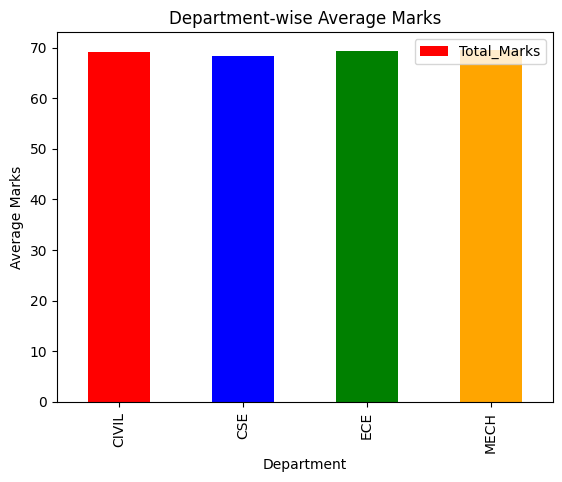

In [35]:
df.groupby("department")["Total_Marks"].mean().plot(
    kind='bar',
    color=['red', 'blue', 'green', 'orange'],
    legend=True
)
plt.title("Department-wise Average Marks")
plt.xlabel("Department")
plt.ylabel("Average Marks")
plt.show()

# piechart

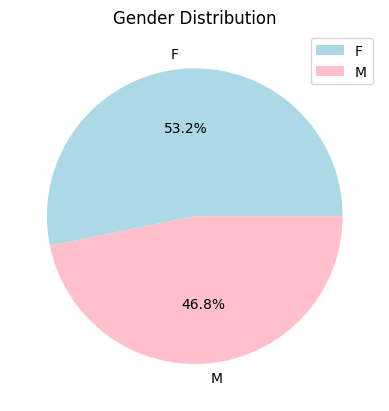

In [42]:
df["gender"].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['lightblue', 'pink'],
    legend=True
)
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

# Histogram

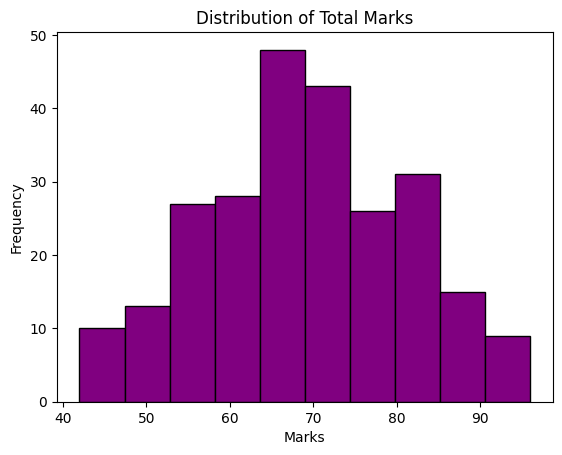

In [44]:
from matplotlib import legend
plt.hist(
    df["Total_Marks"],
    color='purple',
    edgecolor='black'
)
plt.title("Distribution of Total Marks")
plt.xlabel("Marks")
plt.ylabel("Frequency")
plt.show()

# Scatterplots

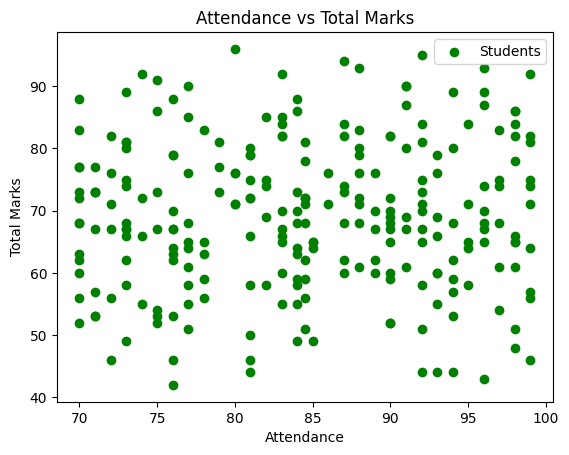

In [46]:
plt.scatter(
    df["Attendance"],
    df["Total_Marks"],
    color='green',
    label="Students"
)
plt.title("Attendance vs Total Marks")
plt.xlabel("Attendance")
plt.ylabel("Total Marks")
plt.legend()
plt.show()

# Insights

In [34]:
print("\nInsights:")
print("- Higher attendance generally leads to better marks.")
print("- Some departments perform better on average.")
print("- Internal marks strongly influence total marks.")


Insights:
- Higher attendance generally leads to better marks.
- Some departments perform better on average.
- Internal marks strongly influence total marks.
